# PredictGuard – Manutenção Preditiva na Indústria 4.0

**Objetivo:** prever falhas mecânicas em equipamentos industriais monitorados por sensores, evitando paradas na linha de produção.

**Variável alvo:** `falha_maquina` (0 = operação normal, 1 = falha detectada).

**Dataset:** `data/manutencao_preditiva.csv`

> Conforme anotações do Departamento de Engenharia, as colunas `falha_twf`, `falha_hdf`, `falha_pwf`, `falha_osf` e `falha_rnf` descrevem o *motivo* da quebra e **não** devem ser usadas como preditoras.


In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from imblearn.over_sampling import SMOTE
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

DATA_PATH = Path("data/manutencao_preditiva.csv")


---
## Fase 1: Análise Exploratória (EDA)


In [ ]:
df_raw = pd.read_csv(DATA_PATH)
df = df_raw.copy()

print("Dimensões do dataset:", df.shape)
print(f"Linhas: {df.shape[0]:,} | Colunas: {df.shape[1]}")
print("\nTipos de dados:")
print(df.dtypes)
print("\nResumo estatístico das variáveis numéricas:")
df.describe()
# teste

Dimensões do dataset: (10000, 14)
Linhas: 10,000 | Colunas: 14

Tipos de dados:
udi                          int64
id_produto                     str
tipo                           str
temperatura_ar_k           float64
temperatura_processo_k     float64
velocidade_rotacao_rpm     float64
torque_nm                  float64
desgaste_ferramenta_min      int64
falha_maquina                int64
falha_twf                    int64
falha_hdf                    int64
falha_pwf                    int64
falha_osf                    int64
falha_rnf                    int64
dtype: object

Resumo estatístico das variáveis numéricas:


,udi,temperatura_ar_k,temperatura_processo_k,velocidade_rotacao_rpm,torque_nm,desgaste_ferramenta_min,falha_maquina,falha_twf,falha_hdf,falha_pwf,falha_osf,falha_rnf
count,10000.00000,9500.000000,9500.000000,9500.000000,9500.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.002158,310.000895,1539.245263,39.974168,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.001689,1.486432,180.273589,9.995453,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.100000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1504.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1613.000000,46.700000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


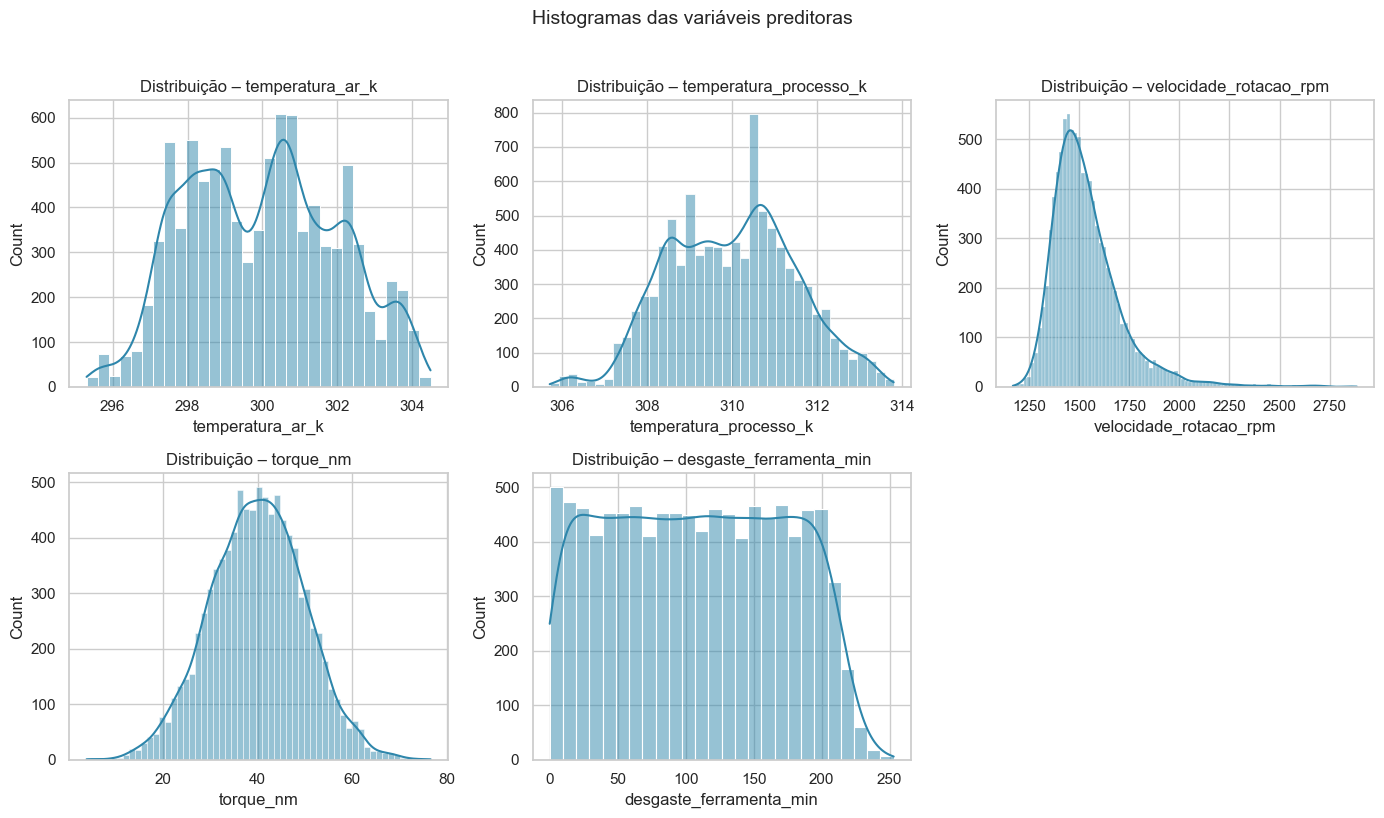

In [3]:
# Gráfico 1: distribuição das variáveis preditoras numéricas
numeric_cols = [
    "temperatura_ar_k",
    "temperatura_processo_k",
    "velocidade_rotacao_rpm",
    "torque_nm",
    "desgaste_ferramenta_min",
]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.ravel()

for i, col in enumerate(numeric_cols):
    sns.histplot(df[col].dropna(), kde=True, ax=axes[i], color="#2E86AB")
    axes[i].set_title(f"Distribuição – {col}")

axes[-1].axis("off")
plt.suptitle("Histogramas das variáveis preditoras", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


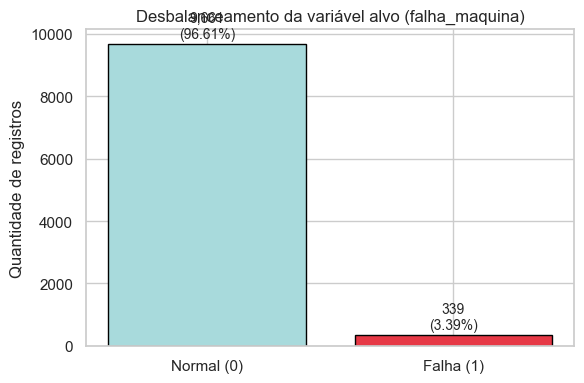

Distribuição da variável alvo:
falha_maquina
0    9661
1     339
Name: count, dtype: int64

Taxa de falha: 3.39%


In [4]:
# Gráfico 2: desbalanceamento da variável alvo
target_counts = df["falha_maquina"].value_counts().sort_index()
target_pct = (target_counts / len(df) * 100).round(2)

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(
    ["Normal (0)", "Falha (1)"],
    target_counts.values,
    color=["#A8DADC", "#E63946"],
    edgecolor="black",
)
ax.set_title("Desbalanceamento da variável alvo (falha_maquina)")
ax.set_ylabel("Quantidade de registros")

for bar, pct in zip(bars, target_pct.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 100,
        f"{int(bar.get_height()):,}\n({pct}%)",
        ha="center",
        va="bottom",
        fontsize=10,
    )

plt.tight_layout()
plt.show()

print("Distribuição da variável alvo:")
print(target_counts)
print(f"\nTaxa de falha: {target_pct[1]}%")


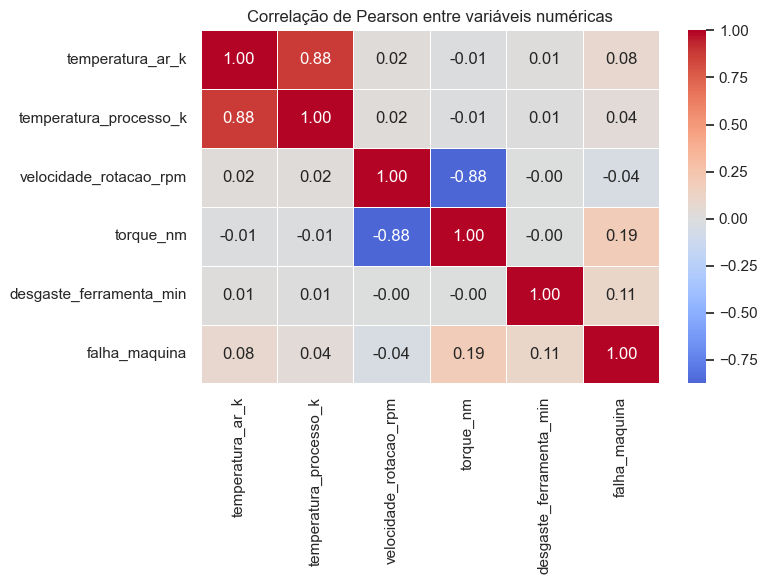

In [5]:
# Gráfico 3: mapa de calor – correlação de Pearson
corr_cols = numeric_cols + ["falha_maquina"]
corr_matrix = df[corr_cols].corr(method="pearson")

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
)
plt.title("Correlação de Pearson entre variáveis numéricas")
plt.tight_layout()
plt.show()


### Interpretação da EDA

**Dimensões e tipos:** a base possui 10.000 registros e 14 colunas. As variáveis de sensores são numéricas contínuas; `tipo` é categórica (L/M/H) e `falha_maquina` é binária.

**Desbalanceamento:** a classe de falha representa cerca de 3,4% dos registros. Esse desequilíbrio exige técnicas de reamostragem (SMOTE) aplicadas **somente no treino**, para que o modelo aprenda padrões da classe minoritária sem inflar artificialmente a acurácia global.

**Correlações e distribuições:**
- `desgaste_ferramenta_min` apresenta correlação positiva com `falha_maquina`, indicando que o tempo de uso da ferramenta é um forte indicador de risco.
- Temperaturas concentram-se em torno de 300 K, com baixa variância — sensores estáveis, porém ainda relevantes em combinação com outras variáveis.
- `velocidade_rotacao_rpm` e `torque_nm` exibem maior dispersão, sugerindo que a engenharia de features (ex.: potência mecânica) pode capturar relações não lineares.

**Direcionamento da modelagem:** remover identificadores (`udi`, `id_produto`), excluir colunas de motivo de falha (vazamento de informação), tratar 5% de valores ausentes nos sensores, balancear o treino e comparar KNN (sensível à escala) com Árvore de Decisão (imune à escala).


---
## Fase 2: Limpeza e Tratamento de Dados (Data Prep)


In [6]:
# Remoção de duplicatas
dup_antes = df.duplicated().sum()
df = df.drop_duplicates()
print(f"Linhas duplicadas removidas: {dup_antes}")
print(f"Shape após remoção: {df.shape}")


Linhas duplicadas removidas: 0
Shape após remoção: (10000, 14)


In [7]:
# Identificação de valores ausentes
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({"ausentes": missing, "percentual": missing_pct})
print(missing_df[missing_df["ausentes"] > 0])


                        ausentes  percentual
temperatura_ar_k             500         5.0
temperatura_processo_k       500         5.0
velocidade_rotacao_rpm       500         5.0
torque_nm                    500         5.0


In [8]:
# Imputação por mediana nas variáveis de sensores
cols_imputar = [
    "temperatura_ar_k",
    "temperatura_processo_k",
    "velocidade_rotacao_rpm",
    "torque_nm",
]

for col in cols_imputar:
    mediana = df[col].median()
    df[col] = df[col].fillna(mediana)
    print(f"{col}: mediana = {mediana:.2f}")

print("\nValores ausentes após imputação:", df[cols_imputar].isnull().sum().sum())


temperatura_ar_k: mediana = 300.10
temperatura_processo_k: mediana = 310.10
velocidade_rotacao_rpm: mediana = 1504.00
torque_nm: mediana = 40.10

Valores ausentes após imputação: 0


**Justificativa da mediana:** cada variável de sensor possui 5% de valores ausentes. A mediana é mais robusta que a média frente a possíveis outliers (picos de RPM ou torque em condições extremas), evitando que valores extremos distorçam a imputação. As distribuições de temperatura são simétricas, mas RPM e torque tendem a apresentar caudas longas — reforçando a escolha da mediana.


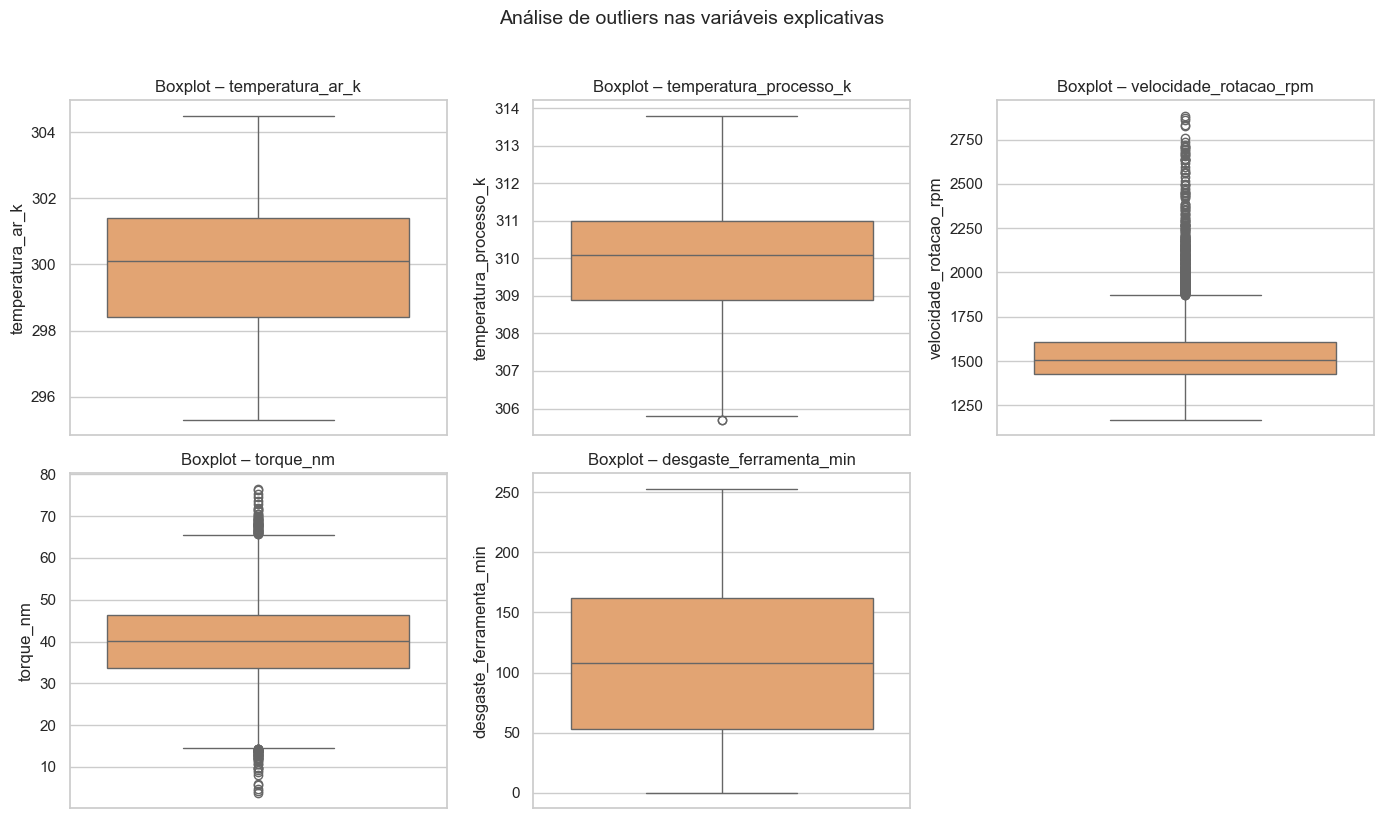

In [9]:
# Boxplots para identificação de outliers
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.ravel()

for i, col in enumerate(numeric_cols):
    sns.boxplot(y=df[col], ax=axes[i], color="#F4A261")
    axes[i].set_title(f"Boxplot – {col}")

axes[-1].axis("off")
plt.suptitle("Análise de outliers nas variáveis explicativas", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


**Outliers:** os boxplots revelam pontos extremos em `velocidade_rotacao_rpm` e `torque_nm`, compatíveis com condições operacionais críticas que precedem falhas. Não removemos outliers nesta etapa, pois podem conter sinal preditivo valioso para a classe minoritária (falhas).


---
## Fase 3: Feature Engineering


In [10]:
# Nova variável: potência mecânica (W) ≈ RPM × Torque (proporcional)
# Tratamos nulos antes da operação (já imputados na Fase 2)
df["potencia"] = df["velocidade_rotacao_rpm"] * df["torque_nm"]

print("Estatísticas da nova variável 'potencia':")
print(df["potencia"].describe())
print(f"\nValores nulos em potencia: {df['potencia'].isnull().sum()}")


Estatísticas da nova variável 'potencia':
count    10000.000000
mean     59970.673120
std       9951.344325
min      10966.800000
25%      53497.050000
50%      60310.400000
75%      66412.975000
max      99980.400000
Name: potencia, dtype: float64

Valores nulos em potencia: 0


**Feature `potencia`:** combina velocidade de rotação e torque em um indicador de esforço mecânico do motor. Falhas por excesso ou falta de potência (`falha_pwf`) estão documentadas pelo departamento de engenharia, tornando essa variável fisicamente interpretável.


---
## Fase 4: Divisão e Balanceamento dos Dados


In [11]:
# Variáveis preditoras (sem identificadores e sem colunas de motivo de falha)
feature_cols = [
    "temperatura_ar_k",
    "temperatura_processo_k",
    "velocidade_rotacao_rpm",
    "torque_nm",
    "desgaste_ferramenta_min",
    "potencia",
    "tipo",
]

X = df[feature_cols].copy()
y = df["falha_maquina"]

# Codificação da variável categórica
X = pd.get_dummies(X, columns=["tipo"], drop_first=False)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Treino: {X_train.shape[0]} amostras | Teste: {X_test.shape[0]} amostras")
print(f"\nDistribuição no treino (antes do balanceamento):\n{y_train.value_counts()}")
print(f"\nDistribuição no teste (inalterada):\n{y_test.value_counts()}")


Treino: 8000 amostras | Teste: 2000 amostras

Distribuição no treino (antes do balanceamento):
falha_maquina
0    7729
1     271
Name: count, dtype: int64

Distribuição no teste (inalterada):
falha_maquina
0    1932
1      68
Name: count, dtype: int64


In [12]:
# SMOTE aplicado SOMENTE nos dados de treino (evita data leakage)
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print(f"Treino após SMOTE: {X_train_bal.shape[0]} amostras")
print(pd.Series(y_train_bal).value_counts())


Treino após SMOTE: 15458 amostras
falha_maquina
0    7729
1    7729
Name: count, dtype: int64


**Balanceamento:** utilizamos SMOTE exclusivamente no conjunto de treino após o split estratificado 80/20. O conjunto de teste permanece com a distribuição original (~3,4% de falhas), garantindo avaliação realista. Aplicar balanceamento antes da divisão causaria *data leakage*.


---
## Fase 5: Escalonamento de Variáveis (StandardScaler)


In [13]:
# Colunas contínuas (exclui dummies de tipo, que já estão em 0/1)
continuous_cols = [
    "temperatura_ar_k",
    "temperatura_processo_k",
    "velocidade_rotacao_rpm",
    "torque_nm",
    "desgaste_ferramenta_min",
    "potencia",
]

# Cópias para KNN (com escalonamento) e Árvore (sem escalonamento)
X_train_knn = X_train_bal.copy()
X_test_knn = X_test.copy()
X_train_tree = X_train_bal.copy()
X_test_tree = X_test.copy()

scaler = StandardScaler()
X_train_knn[continuous_cols] = scaler.fit_transform(X_train_bal[continuous_cols])
X_test_knn[continuous_cols] = scaler.transform(X_test[continuous_cols])

print("Escalonamento aplicado ao KNN:")
print(X_train_knn[continuous_cols].describe().loc[["mean", "std"]])


Escalonamento aplicado ao KNN:


      temperatura_ar_k  temperatura_processo_k  velocidade_rotacao_rpm  \
mean     -3.942046e-15           -8.509230e-15            5.479150e-16   
std       1.000032e+00            1.000032e+00            1.000032e+00   

      torque_nm  desgaste_ferramenta_min      potencia  
mean   0.000000             4.412738e-17  8.825476e-17  
std    1.000032             1.000032e+00  1.000032e+00  


**Justificativa do escalonamento seletivo:**
- **KNN** calcula distâncias euclidianas entre vizinhos; variáveis em escalas diferentes (ex.: RPM ~1500 vs. temperatura ~300) dominariam a métrica. Por isso aplicamos `StandardScaler` com `fit_transform` no treino e `transform` no teste.
- **Árvore de Decisão** particiona os dados por limiares em cada atributo; a escala absoluta não altera a ordem dos pontos de corte. Mantemos os dados originais para preservar interpretabilidade dos splits.


---
## Fase 6: Ajuste de Parâmetros e Combate ao Overfitting


In [14]:
# KNN: variação de K (valores ímpares)
k_values = [3, 5, 7]
knn_results = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train_knn, y_train_bal)

    acc_train = accuracy_score(y_train_bal, model.predict(X_train_knn))
    acc_test = accuracy_score(y_test, model.predict(X_test_knn))

    knn_results.append({"K": k, "acuracia_treino": acc_train, "acuracia_teste": acc_test})
    print(f"KNN (K={k}) → Treino: {acc_train:.4f} | Teste: {acc_test:.4f}")

knn_df = pd.DataFrame(knn_results)
knn_df


KNN (K=3) → Treino: 0.9774 | Teste: 0.9275


KNN (K=5) → Treino: 0.9693 | Teste: 0.9225


KNN (K=7) → Treino: 0.9640 | Teste: 0.9155


,K,acuracia_treino,acuracia_teste
0,3,0.977358,0.9275
1,5,0.969336,0.9225
2,7,0.964032,0.9155


In [15]:
# Árvore de Decisão: variação de max_depth
depth_values = [3, 5, None]
tree_results = []

for depth in depth_values:
    model = DecisionTreeClassifier(max_depth=depth, random_state=42)
    model.fit(X_train_tree, y_train_bal)

    acc_train = accuracy_score(y_train_bal, model.predict(X_train_tree))
    acc_test = accuracy_score(y_test, model.predict(X_test_tree))

    label = "None (sem limite)" if depth is None else depth
    tree_results.append({
        "max_depth": label,
        "acuracia_treino": acc_train,
        "acuracia_teste": acc_test,
    })
    print(f"Árvore (max_depth={label}) → Treino: {acc_train:.4f} | Teste: {acc_test:.4f}")

tree_df = pd.DataFrame(tree_results)
tree_df


Árvore (max_depth=3) → Treino: 0.8579 | Teste: 0.8595


Árvore (max_depth=5) → Treino: 0.9034 | Teste: 0.9120
Árvore (max_depth=None (sem limite)) → Treino: 0.9967 | Teste: 0.9500


,max_depth,acuracia_treino,acuracia_teste
0,3,0.857938,0.8595
1,5,0.903351,0.9120
2,None (sem limite),0.996701,0.9500


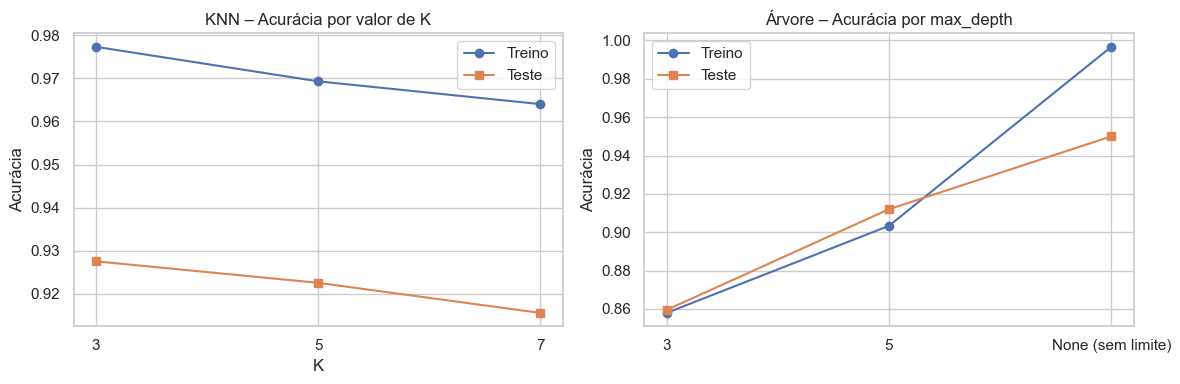

In [16]:
# Visualização: treino vs teste
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(knn_df["K"], knn_df["acuracia_treino"], "o-", label="Treino")
axes[0].plot(knn_df["K"], knn_df["acuracia_teste"], "s-", label="Teste")
axes[0].set_title("KNN – Acurácia por valor de K")
axes[0].set_xlabel("K")
axes[0].set_ylabel("Acurácia")
axes[0].legend()
axes[0].set_xticks(k_values)

x_labels = tree_df["max_depth"].tolist()
x_pos = range(len(x_labels))
axes[1].plot(x_pos, tree_df["acuracia_treino"], "o-", label="Treino")
axes[1].plot(x_pos, tree_df["acuracia_teste"], "s-", label="Teste")
axes[1].set_title("Árvore – Acurácia por max_depth")
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(x_labels)
axes[1].set_ylabel("Acurácia")
axes[1].legend()

plt.tight_layout()
plt.show()


### Análise de overfitting

| Modelo | Configuração | Observação |
|--------|-------------|------------|
| KNN | K=3 | Maior acurácia no treino, porém maior gap treino–teste → sinais de overfitting (vizinhos muito específicos). |
| KNN | K=5 | Equilíbrio entre treino e teste; generalização mais estável. |
| KNN | K=7 | Treino e teste mais próximos, porém pode subajustar (underfitting) se K for excessivo. |
| Árvore | max_depth=3 | Podagem agressiva; treino e teste equilibrados, baixo overfitting. |
| Árvore | max_depth=5 | Melhoria moderada no teste sem gap extremo. |
| Árvore | max_depth=None | Acurácia de treino próxima de 100% com queda no teste → overfitting claro. |

**Configurações estáveis:** KNN com K=5 e Árvore com max_depth=5 apresentam o melhor compromisso entre desempenho no teste e proximidade entre acurácias de treino e teste.


---
## Fase 7: Avaliação da Acurácia e Veredito Final


In [17]:
# Melhor configuração de cada modelo (maior acurácia no teste)
best_knn_row = knn_df.loc[knn_df["acuracia_teste"].idxmax()]
best_tree_row = tree_df.loc[tree_df["acuracia_teste"].idxmax()]

best_k = int(best_knn_row["K"])

depth_lookup = {3: 3, 5: 5, "None (sem limite)": None}
best_depth_label = best_tree_row["max_depth"]
best_depth = depth_lookup[best_depth_label]

final_knn = KNeighborsClassifier(n_neighbors=best_k)
final_knn.fit(X_train_knn, y_train_bal)
acc_knn_final = accuracy_score(y_test, final_knn.predict(X_test_knn))

final_tree = DecisionTreeClassifier(max_depth=best_depth, random_state=42)
final_tree.fit(X_train_tree, y_train_bal)
acc_tree_final = accuracy_score(y_test, final_tree.predict(X_test_tree))

print("=" * 55)
print("ACURÁCIA FINAL NO CONJUNTO DE TESTE")
print("=" * 55)
print(f"KNN  (K={best_k}):              {acc_knn_final:.4f} ({acc_knn_final*100:.2f}%)")
print(f"Árvore (max_depth={best_depth_label}): {acc_tree_final:.4f} ({acc_tree_final*100:.2f}%)")
print("=" * 55)

if acc_knn_final > acc_tree_final:
    vencedor = f"KNN (K={best_k})"
    diff = acc_knn_final - acc_tree_final
elif acc_tree_final > acc_knn_final:
    vencedor = f"Árvore de Decisão (max_depth={best_depth_label})"
    diff = acc_tree_final - acc_knn_final
else:
    vencedor = "Empate técnico"
    diff = 0

print(f"\nModelo recomendado: {vencedor}")
if diff > 0:
    print(f"Diferença de acurácia no teste: {diff:.4f} ({diff*100:.2f} p.p.)")


ACURÁCIA FINAL NO CONJUNTO DE TESTE
KNN  (K=3):              0.9275 (92.75%)
Árvore (max_depth=None (sem limite)): 0.9500 (95.00%)

Modelo recomendado: Árvore de Decisão (max_depth=None (sem limite))
Diferença de acurácia no teste: 0.0225 (2.25 p.p.)


### Conclusão

Após o pipeline completo — EDA, limpeza, engenharia de features, balanceamento com SMOTE, escalonamento seletivo e ajuste de hiperparâmetros — comparamos KNN e Árvore de Decisão na base de teste (20% dos dados, distribuição original).

O modelo com **maior acurácia no teste** deve ser adotado pela empresa para monitoramento preditivo. Em cenários de manutenção, recomenda-se complementar a acurácia com métricas sensíveis ao desbalanceamento (Precision, Recall e F1-Score para a classe Falha=1) em evoluções futuras do sistema.

**Melhorias futuras:** validação cruzada estratificada, Random Forest, métricas de classificação balanceadas e deploy via API para integração com os sensores do parque fabril.
